In [1]:
# Import required libraries
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Add parent directory to path
sys.path.insert(0, str(Path.cwd().parent))

from config.config import *
from src.models.model1 import BinaryClassificationModel
import src.utils as ut
from sklearn.metrics import accuracy_score, roc_auc_score
from src.databases import PersistenceDiagramDatabaseTE
from persim import wasserstein, bottleneck, plot_diagrams, PersistenceImager

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


In [2]:
# Load train, test datasets
train_dataset = ut.SeismicDataset(data_path=Path("../data/processed/signals_train.hdf5"))
test_dataset = ut.SeismicDataset(data_path=Path("../data/processed/signals_test.hdf5"))

print(f"\n✓ Datasets loaded successfully")
print(f"  Train: {len(train_dataset)} signals")
print(f"  Test: {len(test_dataset)} signals")
print(f"\nSample (signal, label, magnitude): {train_dataset[0]}")


✓ Datasets loaded successfully
  Train: 135 signals
  Test: 36 signals

Sample (signal, label, magnitude): (array([  -124.60970609,    -86.57610512,    -46.54250415, ...,
       -10521.03606728,  -4428.00246631,   9053.03113466]), 1, 4.4)


Unitary test

In [3]:
from src.utils import compute_persistence, takens_embedding

signal0, label0, mag0 = train_dataset[0]
print(f"Signal shape: {signal0.shape}, Label: {label0}, Magnitude: {mag0}")
print(f"Signal stats ; Mean: {np.mean(signal0)}, Std: {np.std(signal0)}, Min: {np.min(signal0)}, Max: {np.max(signal0)}")

Signal shape: (2520,), Label: 1, Magnitude: 4.4
Signal stats ; Mean: -1.1837867546885733e-13, Std: 11532.14368411183, Min: -89180.38874068836, Max: 78806.71206221846


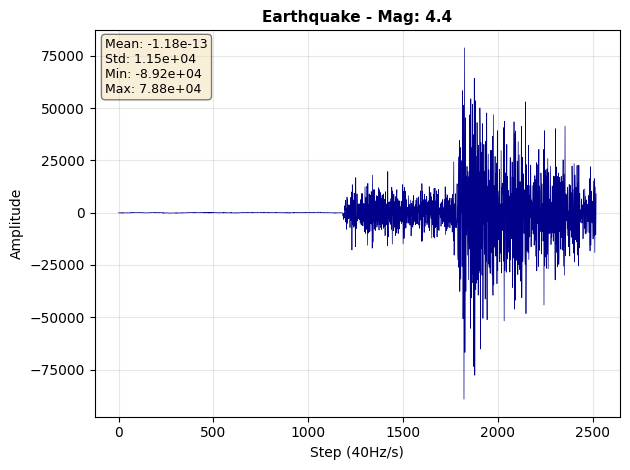

In [4]:
ut.plot_waveform(signal=signal0, label='Earthquake', mag=mag0)

In [5]:
takens_embedding0 = takens_embedding(signal0, dim=100, tau=10)
takens_embedding0.shape

(1530, 100)

In [6]:
takens_embedding0

array([[-1.24609706e+02, -5.92736964e+01, -1.52937687e+02, ...,
         5.09832338e+01,  8.13192435e+01,  1.01655253e+02],
       [-8.65761051e+01, -5.24009543e+00, -1.88904086e+02, ...,
         1.16016835e+02,  3.83528444e+01,  9.56888541e+01],
       [-4.65425042e+01, -1.37206494e+02, -3.18704848e+01, ...,
        -9.49564283e-01,  3.53864454e+01,  7.87224551e+01],
       ...,
       [-5.04330103e+03, -5.94896502e+03,  2.58037099e+03, ...,
        -3.55570809e+03, -5.02037208e+03, -1.05210361e+04],
       [ 4.63732574e+02, -4.06931416e+02,  1.26340459e+03, ...,
        -4.90967449e+03, -1.11333385e+04, -4.42800247e+03],
       [ 8.09876618e+03,  1.85810219e+03, -1.24956181e+03, ...,
         3.37435912e+03,  3.79069512e+03,  9.05303113e+03]])

Manejar 5753 points es muy costoso computacionalmente. Hay que hacer un subsampling.

In [7]:
from gudhi.subsampling import choose_n_farthest_points as fps

# Compute takens_embedding0 if not already defined
signal0, label0, mag0 = train_dataset[0]
takens_embedding0 = takens_embedding(signal0, dim=100, tau=10)

# fps returns the actual points, already as numpy array
fps_points0 = np.array(fps(takens_embedding0, nb_points=500, starting_point=None))
print(f"Original embedding shape: {takens_embedding0.shape}")
print(f"Sampled points shape: {fps_points0.shape}")
print(f"Sample point: {fps_points0[0][:5]}...")  # First 5 values of first point

Original embedding shape: (1530, 100)
Sampled points shape: (500, 100)
Sample point: [-59.90199546 -11.56598577 -62.22997608 -93.89396639  -7.5579567 ]...


Idea: samplear pointclouds 5753 -> 500 points

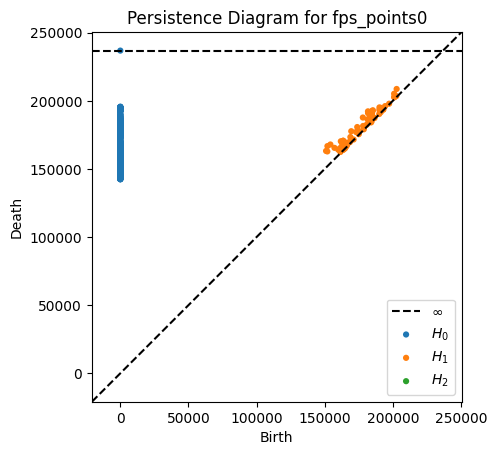

In [8]:
THRESH=1000
# Compute persistence diagram for fps_points0
diagram_fps = compute_persistence(fps_points0, maxdim=2)
plot_diagrams(diagram_fps, show=True, title='Persistence Diagram for fps_points0')

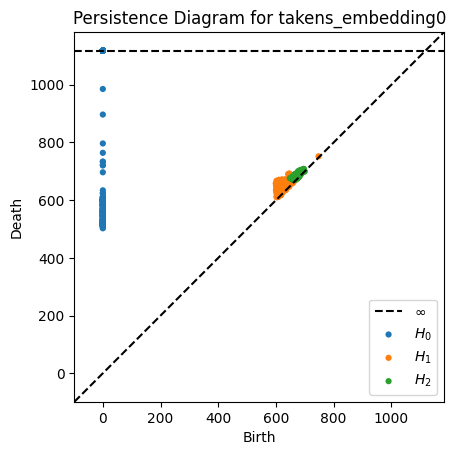

Wasserstein distance between H0 diagrams: 58960888.61395397


In [9]:
# Compute persistence diagram for takens_embedding0 (already done as diagram0)
diagram0 = compute_persistence(takens_embedding0, maxdim=2, thresh=THRESH)
plot_diagrams(diagram0, show=True, title='Persistence Diagram for takens_embedding0')

# Compare using Wasserstein distance
dist = wasserstein(diagram_fps[0], diagram0[0])  # For H0
print(f"Wasserstein distance between H0 diagrams: {dist}")